
  KẾT QUẢ CV – REVENUE
  Fold |     WAPE |            MAE |           RMSE |       R²
--------------------------------------------------------------
     1 |  21.25% |      1,112,653 |      1,539,248 |   0.6723
     2 |  20.12% |      1,166,317 |      1,722,815 |   0.7003
     3 |  30.13% |      1,353,546 |      1,822,323 |   0.5513
     4 |  30.40% |        819,818 |      1,041,004 |   0.5416
     5 |  19.92% |        615,198 |        853,151 |   0.7268
--------------------------------------------------------------
  MEAN |  24.36% |      1,013,506 |      1,395,708 |   0.6385
   STD |   4.84% |        262,668 |        382,043 |   0.0771


  KẾT QUẢ CV – COGS
  Fold |     WAPE |            MAE |           RMSE |       R²
--------------------------------------------------------------
     1 |  19.47% |        881,023 |      1,228,364 |   0.6975
     2 |  18.30% |        917,378 |      1,348,372 |   0.7428
     3 |  30.09% |      1,130,885 |      1,521,997 |   0.5377
     4 |  27.21% | 

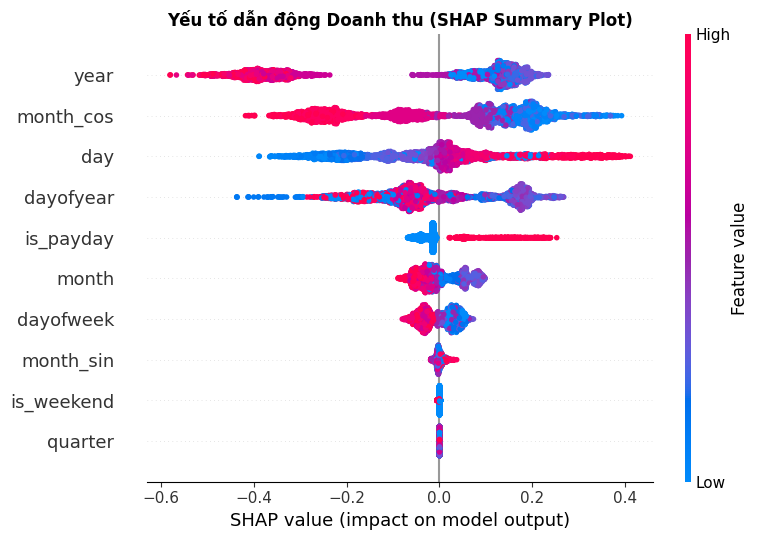

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. CẤU HÌNH & LOAD DỮ LIỆU
# ==========================================
DATA_DIR = '/kaggle/input/datasets/mnmnoiigid/datasetset/dataset/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'

train_df = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
train_df = train_df.sort_values('Date').reset_index(drop=True)
test_df  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
def create_features(df):
    df = df.copy()
    df['year']       = df['Date'].dt.year
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['dayofyear']  = df['Date'].dt.dayofyear
    df['quarter']    = df['Date'].dt.quarter

    # Insight 1 – Payday Effect
    df['is_payday']  = df['day'].isin([1, 2, 3, 28, 29, 30, 31]).astype(int)

    # Insight 2 – Cyclic Encoding cho mùa vụ
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12.0)

    return df

X_train_full = create_features(train_df)
X_test       = create_features(test_df)

FEATURES = [
    'year', 'month', 'day', 'dayofweek', 'is_weekend',
    'dayofyear', 'quarter', 'is_payday', 'month_sin', 'month_cos'
]

TARGET_REV  = 'Revenue'
TARGET_COGS = 'COGS'

# ==========================================
# 3. METRICS HELPERS
# ==========================================
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def print_metrics_table(metrics_per_fold: dict, target_name: str):
    """
    In bảng kết quả từng fold + dòng tổng kết MEAN / STD.
    metrics_per_fold = {
        'WAPE': [...], 'MAE': [...], 'RMSE': [...], 'R2': [...]
    }
    """
    header = f"{'Fold':>6} | {'WAPE':>8} | {'MAE':>14} | {'RMSE':>14} | {'R²':>8}"
    sep    = "-" * len(header)

    print(f"\n{'='*len(header)}")
    print(f"  KẾT QUẢ CV – {target_name.upper()}")
    print(f"{'='*len(header)}")
    print(header)
    print(sep)

    n_folds = len(metrics_per_fold['WAPE'])
    for i in range(n_folds):
        print(
            f"{i+1:>6} | "
            f"{metrics_per_fold['WAPE'][i]:>7.2%} | "
            f"{metrics_per_fold['MAE'][i]:>14,.0f} | "
            f"{metrics_per_fold['RMSE'][i]:>14,.0f} | "
            f"{metrics_per_fold['R2'][i]:>8.4f}"
        )

    print(sep)

    # MEAN
    means = {k: np.mean(v) for k, v in metrics_per_fold.items()}
    stds  = {k: np.std(v)  for k, v in metrics_per_fold.items()}

    print(
        f"{'MEAN':>6} | "
        f"{means['WAPE']:>7.2%} | "
        f"{means['MAE']:>14,.0f} | "
        f"{means['RMSE']:>14,.0f} | "
        f"{means['R2']:>8.4f}"
    )
    # STD
    print(
        f"{'STD':>6} | "
        f"{stds['WAPE']:>7.2%} | "
        f"{stds['MAE']:>14,.0f} | "
        f"{stds['RMSE']:>14,.0f} | "
        f"{stds['R2']:>8.4f}"
    )
    print(f"{'='*len(header)}\n")

# ==========================================
# 4. TRAINING
# ==========================================
tscv = TimeSeriesSplit(n_splits=5)

LGB_PARAMS = dict(
    n_estimators     = 1500,
    learning_rate    = 0.03,
    max_depth        = 7,
    num_leaves       = 31,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    importance_type  = 'gain',
    verbosity        = -1,
)

def train_lgb_target(target_name):
    models  = []
    metrics = {'WAPE': [], 'MAE': [], 'RMSE': [], 'R2': []}

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
        X_tr = X_train_full.loc[train_idx, FEATURES]
        X_va = X_train_full.loc[val_idx,   FEATURES]

        # Log1p transform – Insight 3 (cấu trúc hàm lồi / Zipf-like)
        y_tr       = np.log1p(X_train_full.loc[train_idx, target_name])
        y_va_log   = np.log1p(X_train_full.loc[val_idx,   target_name])
        y_va_actual = X_train_full.loc[val_idx, target_name]

        model = lgb.LGBMRegressor(**LGB_PARAMS)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va_log)],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
        )

        # Inverse transform
        preds_actual = np.expm1(model.predict(X_va))

        # Ghi metrics từng fold
        metrics['WAPE'].append(calculate_wape(y_va_actual, preds_actual))
        metrics['MAE'].append(mean_absolute_error(y_va_actual, preds_actual))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_va_actual, preds_actual)))
        metrics['R2'].append(r2_score(y_va_actual, preds_actual))

        models.append(model)

    # In bảng sau khi chạy xong tất cả fold
    print_metrics_table(metrics, target_name)
    return models

models_rev  = train_lgb_target(TARGET_REV)
models_cogs = train_lgb_target(TARGET_COGS)

# ==========================================
# 5. SHAP – GIẢI THÍCH MÔ HÌNH
# ==========================================
print("--- TẠO SHAP SUMMARY PLOT CHO REVENUE ---")
explainer   = shap.TreeExplainer(models_rev[-1])
shap_values = explainer.shap_values(X_train_full[FEATURES])

plt.figure(figsize=(10, 6))
plt.title("Yếu tố dẫn động Doanh thu (SHAP Summary Plot)", fontweight='bold')
shap.summary_plot(shap_values, X_train_full[FEATURES], show=False)
plt.tight_layout()
plt.savefig('shap_revenue_drivers.png', dpi=300, bbox_inches='tight')
print("Đã lưu → shap_revenue_drivers.png")

# ==========================================
# 6. DỰ BÁO TẬP TEST & ENSEMBLE
# ==========================================
print("\n--- DỰ BÁO VÀ ENSEMBLE ---")

test_preds_rev = np.mean(
    [np.expm1(m.predict(X_test[FEATURES])) for m in models_rev], axis=0
)
test_preds_cogs = np.mean(
    [np.expm1(m.predict(X_test[FEATURES])) for m in models_cogs], axis=0
)

# Ràng buộc tài chính
test_preds_rev  = np.clip(test_preds_rev,  0, None)
test_preds_cogs = np.clip(test_preds_cogs, 0, None)
test_preds_cogs = np.minimum(test_preds_cogs, test_preds_rev)

submission = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': test_preds_rev.round(2),
    'COGS':    test_preds_cogs.round(2),
})
submission.to_csv('submission.csv', index=False)
print("✅ Hoàn thành! → submission.csv")

In [2]:
import os
print(os.listdir('/kaggle/working'))

['submission.csv', '__notebook__.ipynb', 'shap_revenue_drivers.png']


In [3]:
pd.read_csv('/kaggle/working/submission.csv').head()

,Date,Revenue,COGS
0,2023-01-01,3138468.55,2679840.06
1,2023-01-02,1918304.36,1613798.77
2,2023-01-03,1763173.05,1451634.03
3,2023-01-04,1753544.21,1430743.68
4,2023-01-05,1770711.95,1417907.99
